# Phase 2: Feature Engineering
In this notebook, we take the raw DuckDB tables, pivot the vital sign measurements into a wide dataframe (mapping min/max/mean ABCDE variables), define comorbidities based on ICD logic, and visualize our continuous datasets.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA_PATH = r"c:\Users\dell\Desktop\emergency-triage-systems\data\modeling_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,stay_id,age,is_male,mortality,resp_rate_mean,resp_rate_max,spo2_min,spo2_mean,heart_rate_mean,heart_rate_max,...,temp_celsius_min,gcs_total_min,diabetes,hypertension,ckd,heart_failure,copd,cancer,liver_disease,stroke
0,38824235,79,1,0,15.090909,17.0,94.0,97.181818,70.454545,84.0,...,36.444444,15.0,1,1,0,0,0,0,0,0
1,34118910,73,0,0,23.800000,28.0,96.0,96.750000,93.000000,99.0,...,36.777778,15.0,0,1,0,0,0,0,0,0
2,33213809,59,0,0,12.800000,14.0,95.0,97.800000,86.400000,89.0,...,36.944444,15.0,1,0,1,0,0,0,0,0
3,35837034,82,1,0,18.500000,23.0,95.0,97.400000,84.594118,92.0,...,36.666667,15.0,1,1,1,1,0,1,0,0
4,36522024,82,1,0,19.500000,22.0,93.0,96.000000,73.250000,80.0,...,36.166667,15.0,1,1,1,1,1,1,0,0


### 1. Comorbidity Prevalence

C:\Users\dell\AppData\Local\Temp\ipykernel_9336\1569224455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prev.values, y=prev.index, palette="viridis")


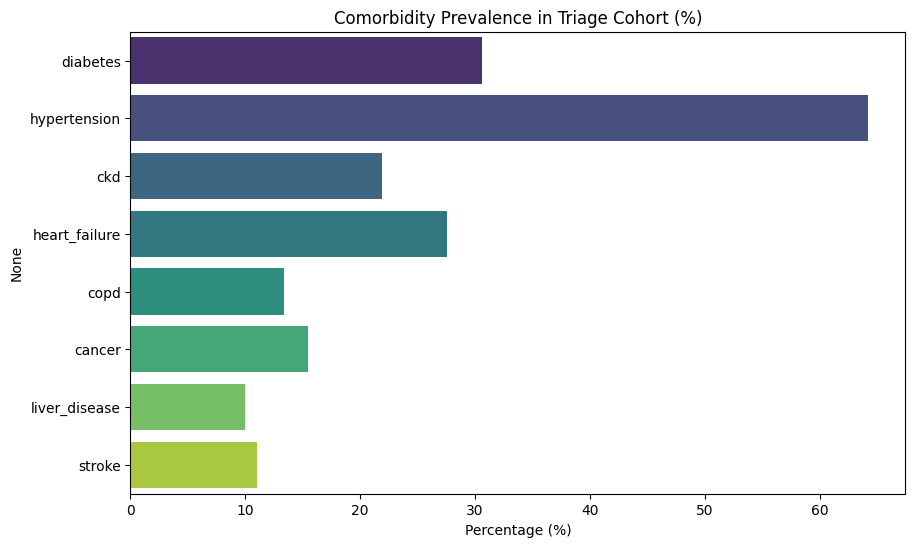

In [ ]:
# Extract binary comorbidity columns 
comorbidities = ['diabetes', 'hypertension', 'ckd', 'heart_failure', 'copd', 'cancer', 'liver_disease', 'stroke']
prev = df[comorbidities].mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=prev.values, y=prev.index, palette="viridis")
plt.title("Comorbidity Prevalence in Triage Cohort (%)")
plt.xlabel("Percentage (%)")
plt.show()

### 2. Imputed Values Verification

Missing Values Post-Imputation:
0 Missing Values Remaining


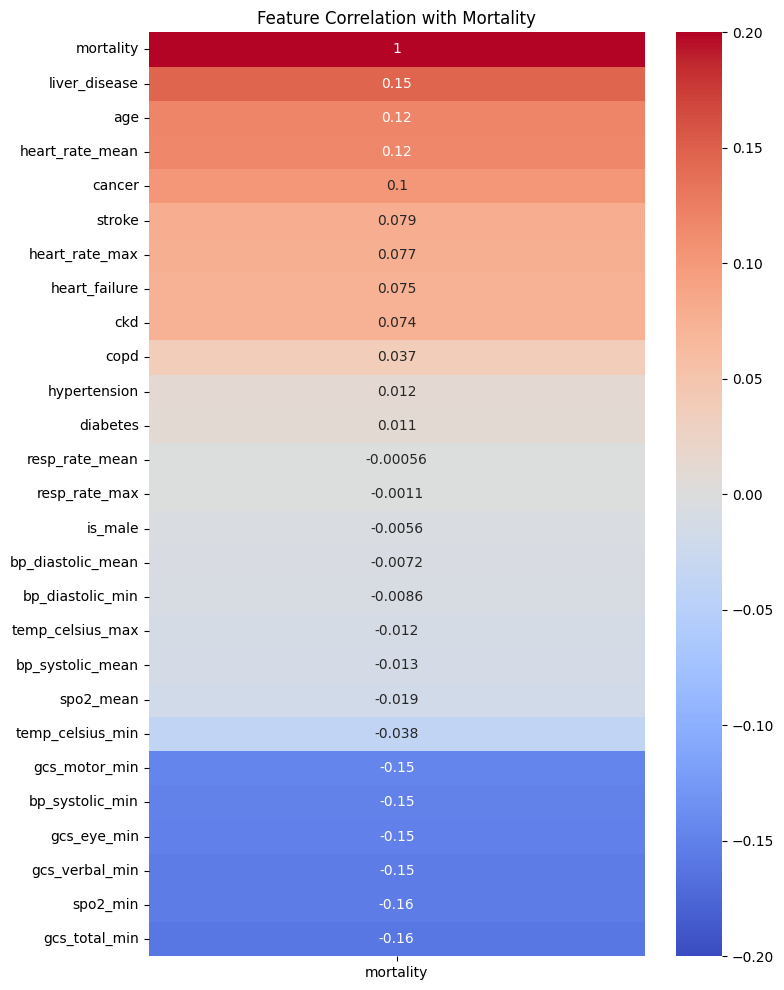

In [3]:
print("Missing Values Post-Imputation:")
print(df.isnull().sum().sum(), "Missing Values Remaining")

# Correlation matrix of clinical variables touching mortality
corr_cols = [c for c in df.columns if c not in ['stay_id']]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 12))
sns.heatmap(corr[['mortality']].sort_values(by='mortality', ascending=False), annot=True, cmap='coolwarm', vmin=-0.2, vmax=0.2)
plt.title("Feature Correlation with Mortality")
plt.show()